<a href="https://colab.research.google.com/github/naadflwrx/MachineLearning/blob/main/task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [5]:
# import library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# membaca dataset
df = pd.read_csv("/content/gdrive/MyDrive/Praktikum_ML/pertemuan-4/data/calonpembelimobil.csv")

# menampilkan 5 baris pertama data
print("===== 5 Data Teratas =====")
print(df.head())

# melihat informasi data
print("\n===== Info Dataset =====")
print(df.info())

# melihat statistik deskriptif
print("\n===== Statistik Deskriptif =====")
print(df.describe())


===== 5 Data Teratas =====
   ID  Usia  Status  Kelamin  Memiliki_Mobil  Penghasilan  Beli_Mobil
0   1    32       1        0               0          240           1
1   2    49       2        1               1          100           0
2   3    52       1        0               2          250           1
3   4    26       2        1               1          130           0
4   5    45       3        0               2          237           1

===== Info Dataset =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ID              1000 non-null   int64
 1   Usia            1000 non-null   int64
 2   Status          1000 non-null   int64
 3   Kelamin         1000 non-null   int64
 4   Memiliki_Mobil  1000 non-null   int64
 5   Penghasilan     1000 non-null   int64
 6   Beli_Mobil      1000 non-null   int64
dtypes: int64(7)
memory usage: 54.8

In [6]:
# memisahkan fitur dan target
x = df[['Usia', 'Status', 'Kelamin', 'Memiliki_Mobil', 'Penghasilan']]
y = df['Beli_Mobil']

# membagi data (80% latih, 20% uji)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Jumlah data latih:", len(x_train))
print("Jumlah data uji:", len(x_test))


Jumlah data latih: 800
Jumlah data uji: 200


In [7]:
# membuat model Logistic Regression
model = LogisticRegression()

# melatih model menggunakan data latih
model.fit(x_train, y_train)

# melihat koefisien model
print("\nKoefisien Model:", model.coef_)
print("Intercept:", model.intercept_)



Koefisien Model: [[-0.0182675  -0.15199633 -1.24779954  0.1852555   0.06297028]]
Intercept: [-12.33020165]


In [8]:
# melakukan prediksi pada data uji
y_pred = model.predict(x_test)

# menghitung akurasi model
akurasi = accuracy_score(y_test, y_pred)
print("\nAkurasi Model:", akurasi)

# menampilkan confusion matrix dan classification report
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Akurasi Model: 0.93

Confusion Matrix:
 [[ 55   9]
 [  5 131]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.86      0.89        64
           1       0.94      0.96      0.95       136

    accuracy                           0.93       200
   macro avg       0.93      0.91      0.92       200
weighted avg       0.93      0.93      0.93       200



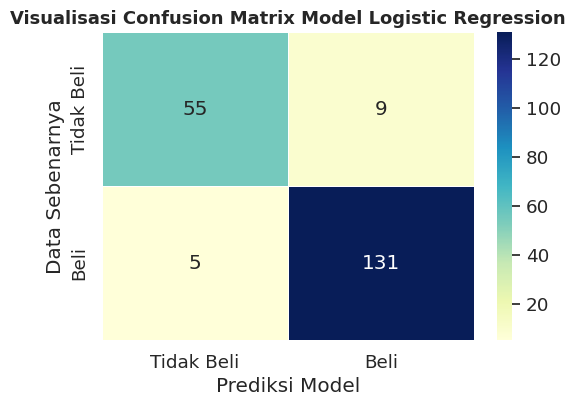

In [9]:
# membuat visualisasi heatmap confusion matrix
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5,
            xticklabels=['Tidak Beli', 'Beli'],
            yticklabels=['Tidak Beli', 'Beli'])
plt.title('Visualisasi Confusion Matrix Model Logistic Regression', fontsize=13, fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Data Sebenarnya')
plt.show()

In [11]:
# dataset baru untuk pengujian model
data_baru = pd.DataFrame({
    'Usia': [28, 45, 21],
    'Status': [1, 3, 1],
    'Kelamin': [1, 0, 1],
    'Memiliki_Mobil': [0, 2, 0],
    'Penghasilan': [180, 320, 100]
})

# prediksi
prediksi_baru = model.predict(data_baru)
data_baru['Prediksi_Beli'] = prediksi_baru

print(data_baru)


   Usia  Status  Kelamin  Memiliki_Mobil  Penghasilan  Prediksi_Beli
0    28       1        1               0          180              0
1    45       3        0               2          320              1
2    21       1        1               0          100              0
